In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_pca, plot_umap, plot_tsne, plot_pca_dark, plot_umap_dark, plot_tsne_dark

# # ---- palette (one place, change here) ----
# PALETTE = "pastel"            # try "muted", "pastel", "Set2", "tab10", "deep"
# sns.set_palette(PALETTE)


/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### CML within-class regime embedding — `cml-small` run (187 blended SPIs)

SPI-SPI feature matrix $f_{ij}=\mathrm{corr}(\mathrm{SPI}_i,\mathrm{SPI}_j)$ over the existing
`data/embeddings/cml-small` run: 10 CML regimes x M in {5,10,20} x T in {500,1000,2000} x 10 instances.
Features generated with `python -m src.process_features --data-path data/embeddings/cml-small --metric pearson`.

Goal: show distinct CML regimes separate in SPI-SPI space, and that the same regime at different (M,T)
co-locates (dimension/length invariance). Pick a regime subset via `SUBSET` below.

##### Candidate regime subsets (ranked)

Ranked by the 5-fold 5-NN regime recall measured on this matrix
(fdstc 1.00, frozen-chaos 0.98, defect-turbulence 0.96, brownian-defect 0.89, sti-i 0.87;
the three traveling-wave variants only confuse *with each other*, so they are merged to one class here).

1. **core-6** *(recommended; = `configs/generate/embeddings/cml-embedding.yaml`)* — maximal dynamical span,
   all subsample-robust: frozen-chaos, brownian-defect, defect-turbulence, sti-i, fdstc, traveling-wave.
2. **turbulence-axis-5** — drops the localized brownian-defect for a clean ordered turbulence progression
   frozen -> STI -> defect-turbulence -> fully-developed, with traveling-wave as an out-group.
3. **cleanest-4** — highest-recall non-redundant quartet, tightest possible embedding for a minimal proof.
4. **all-regimes** — every class in the run (incl. the 3 TW variants, sti-ii, pattern-selection); shows the
   full picture and the expected TW-family overlap.

In [ ]:
# Each entry is a list of mts_class names; None would mean "all regimes".
SUBSETS = {
    "core-6": [
        "frozen-chaos", "brownian-defect", "defect-turbulence",
        "sti-i", "fdstc", "traveling-wave",
    ],
    "turbulence-axis-5": [
        "frozen-chaos", "sti-i", "defect-turbulence", "fdstc", "traveling-wave",
    ],
    "cleanest-4": [
        "fdstc", "frozen-chaos", "defect-turbulence", "sti-i",
    ],
    "test": [
      "brownian-defect", "defect-turbulence", "sti-i", "fdstc", "frozen-chaos",  
    ],
    "1-wave": [
        "brownian-defect", "defect-turbulence", "sti-i", "fdstc", 
        "frozen-chaos", "traveling-wave",
    ],
    "all-regimes": None,   # all 10 classes in the run
}

SUBSET = "cleanest-4"   # <-- change to any key above

In [43]:
data = np.load("../../features/data-embeddings-cml-small_pearson.npz", allow_pickle=True)
X = data["X"]
y = data["y"]
M = data["M"].astype(int)
T = data["T"].astype(int)
instance = data["instance"]
dataset_paths = data["dataset_paths"]

# --- filters (set to None to disable) ---
M_filter = None              # e.g. 20 to inspect a single channel count
classes = SUBSETS[SUBSET]    # None -> all regimes

mask = np.ones(len(y), dtype=bool)
if M_filter is not None:
    mask &= M == M_filter
if classes is not None:
    mask &= np.isin(y, classes)

X = X[mask]
y = y[mask]
M = M[mask]
T = T[mask]
instance = instance[mask]
dataset_paths = dataset_paths[mask]

meta_df = pd.DataFrame({
    "mts_class": y,
    "M": M,
    "T": T,
    "instance": instance,
    "dataset_paths": dataset_paths,
})
print(f"SUBSET={SUBSET}  X: {X.shape}  classes: {np.unique(y).tolist()}")

SUBSET=cleanest-4  X: (360, 15548)  classes: ['defect-turbulence', 'fdstc', 'frozen-chaos', 'sti-i']


In [44]:
df_playing = meta_df.copy()
df_playing.columns

Index(['mts_class', 'M', 'T', 'instance', 'dataset_paths'], dtype='object')

##### Feature matrix

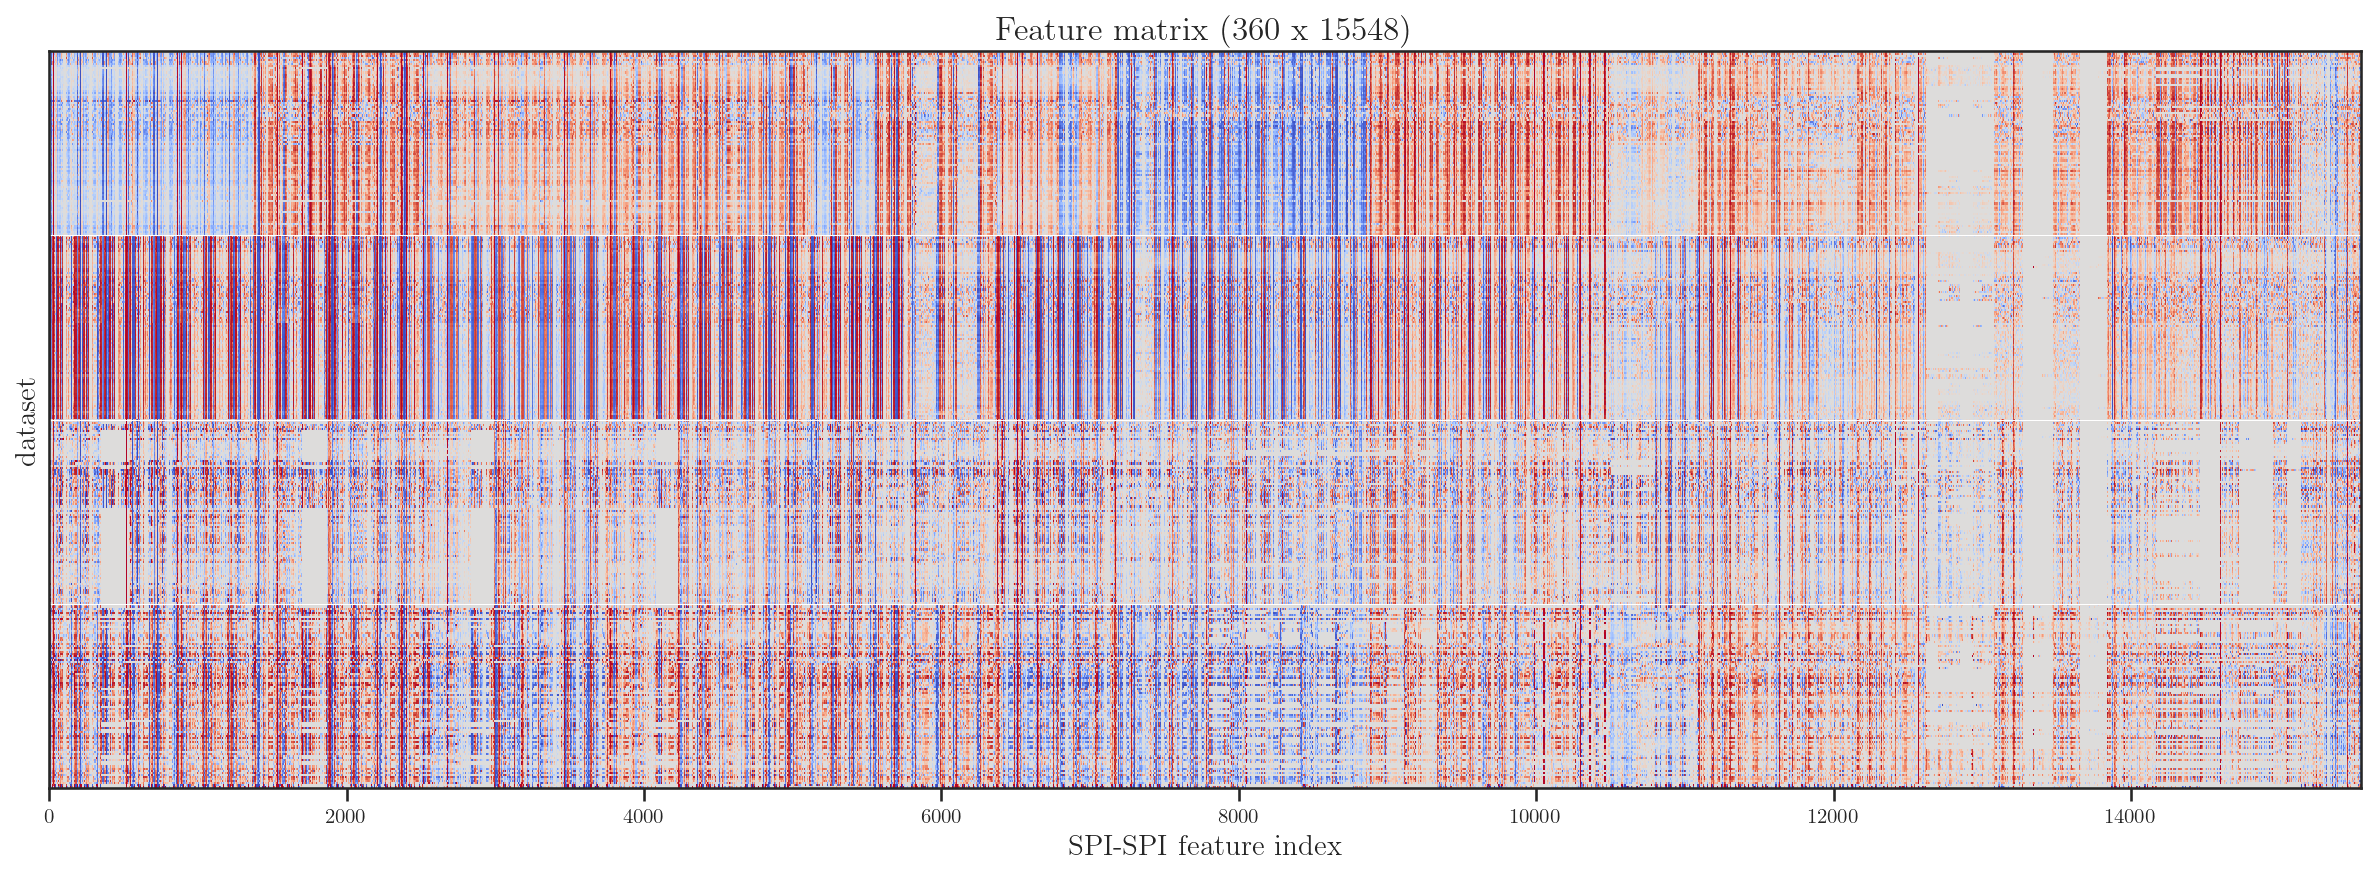

In [45]:
import seaborn as sns

# sort rows by class so blocks are visible
order = np.argsort(y)
X_sorted = X[order]
y_sorted = y[order]

fig, ax = plt.subplots(figsize=(16, 6), dpi=150)
ax.imshow(X_sorted, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1, interpolation="none")
ax.set_xlabel("SPI-SPI feature index")
ax.set_ylabel("dataset")
ax.set_yticks([])
ax.set_title(f"Feature matrix ({X_sorted.shape[0]} x {X_sorted.shape[1]})")

# class boundaries
boundaries = np.where(np.diff(np.searchsorted(np.unique(y_sorted), y_sorted)))[0] + 0.5
for b in boundaries:
    ax.axhline(b, color="white", linewidth=0.5)

plt.tight_layout()
plt.show()

##### PCA - 2D

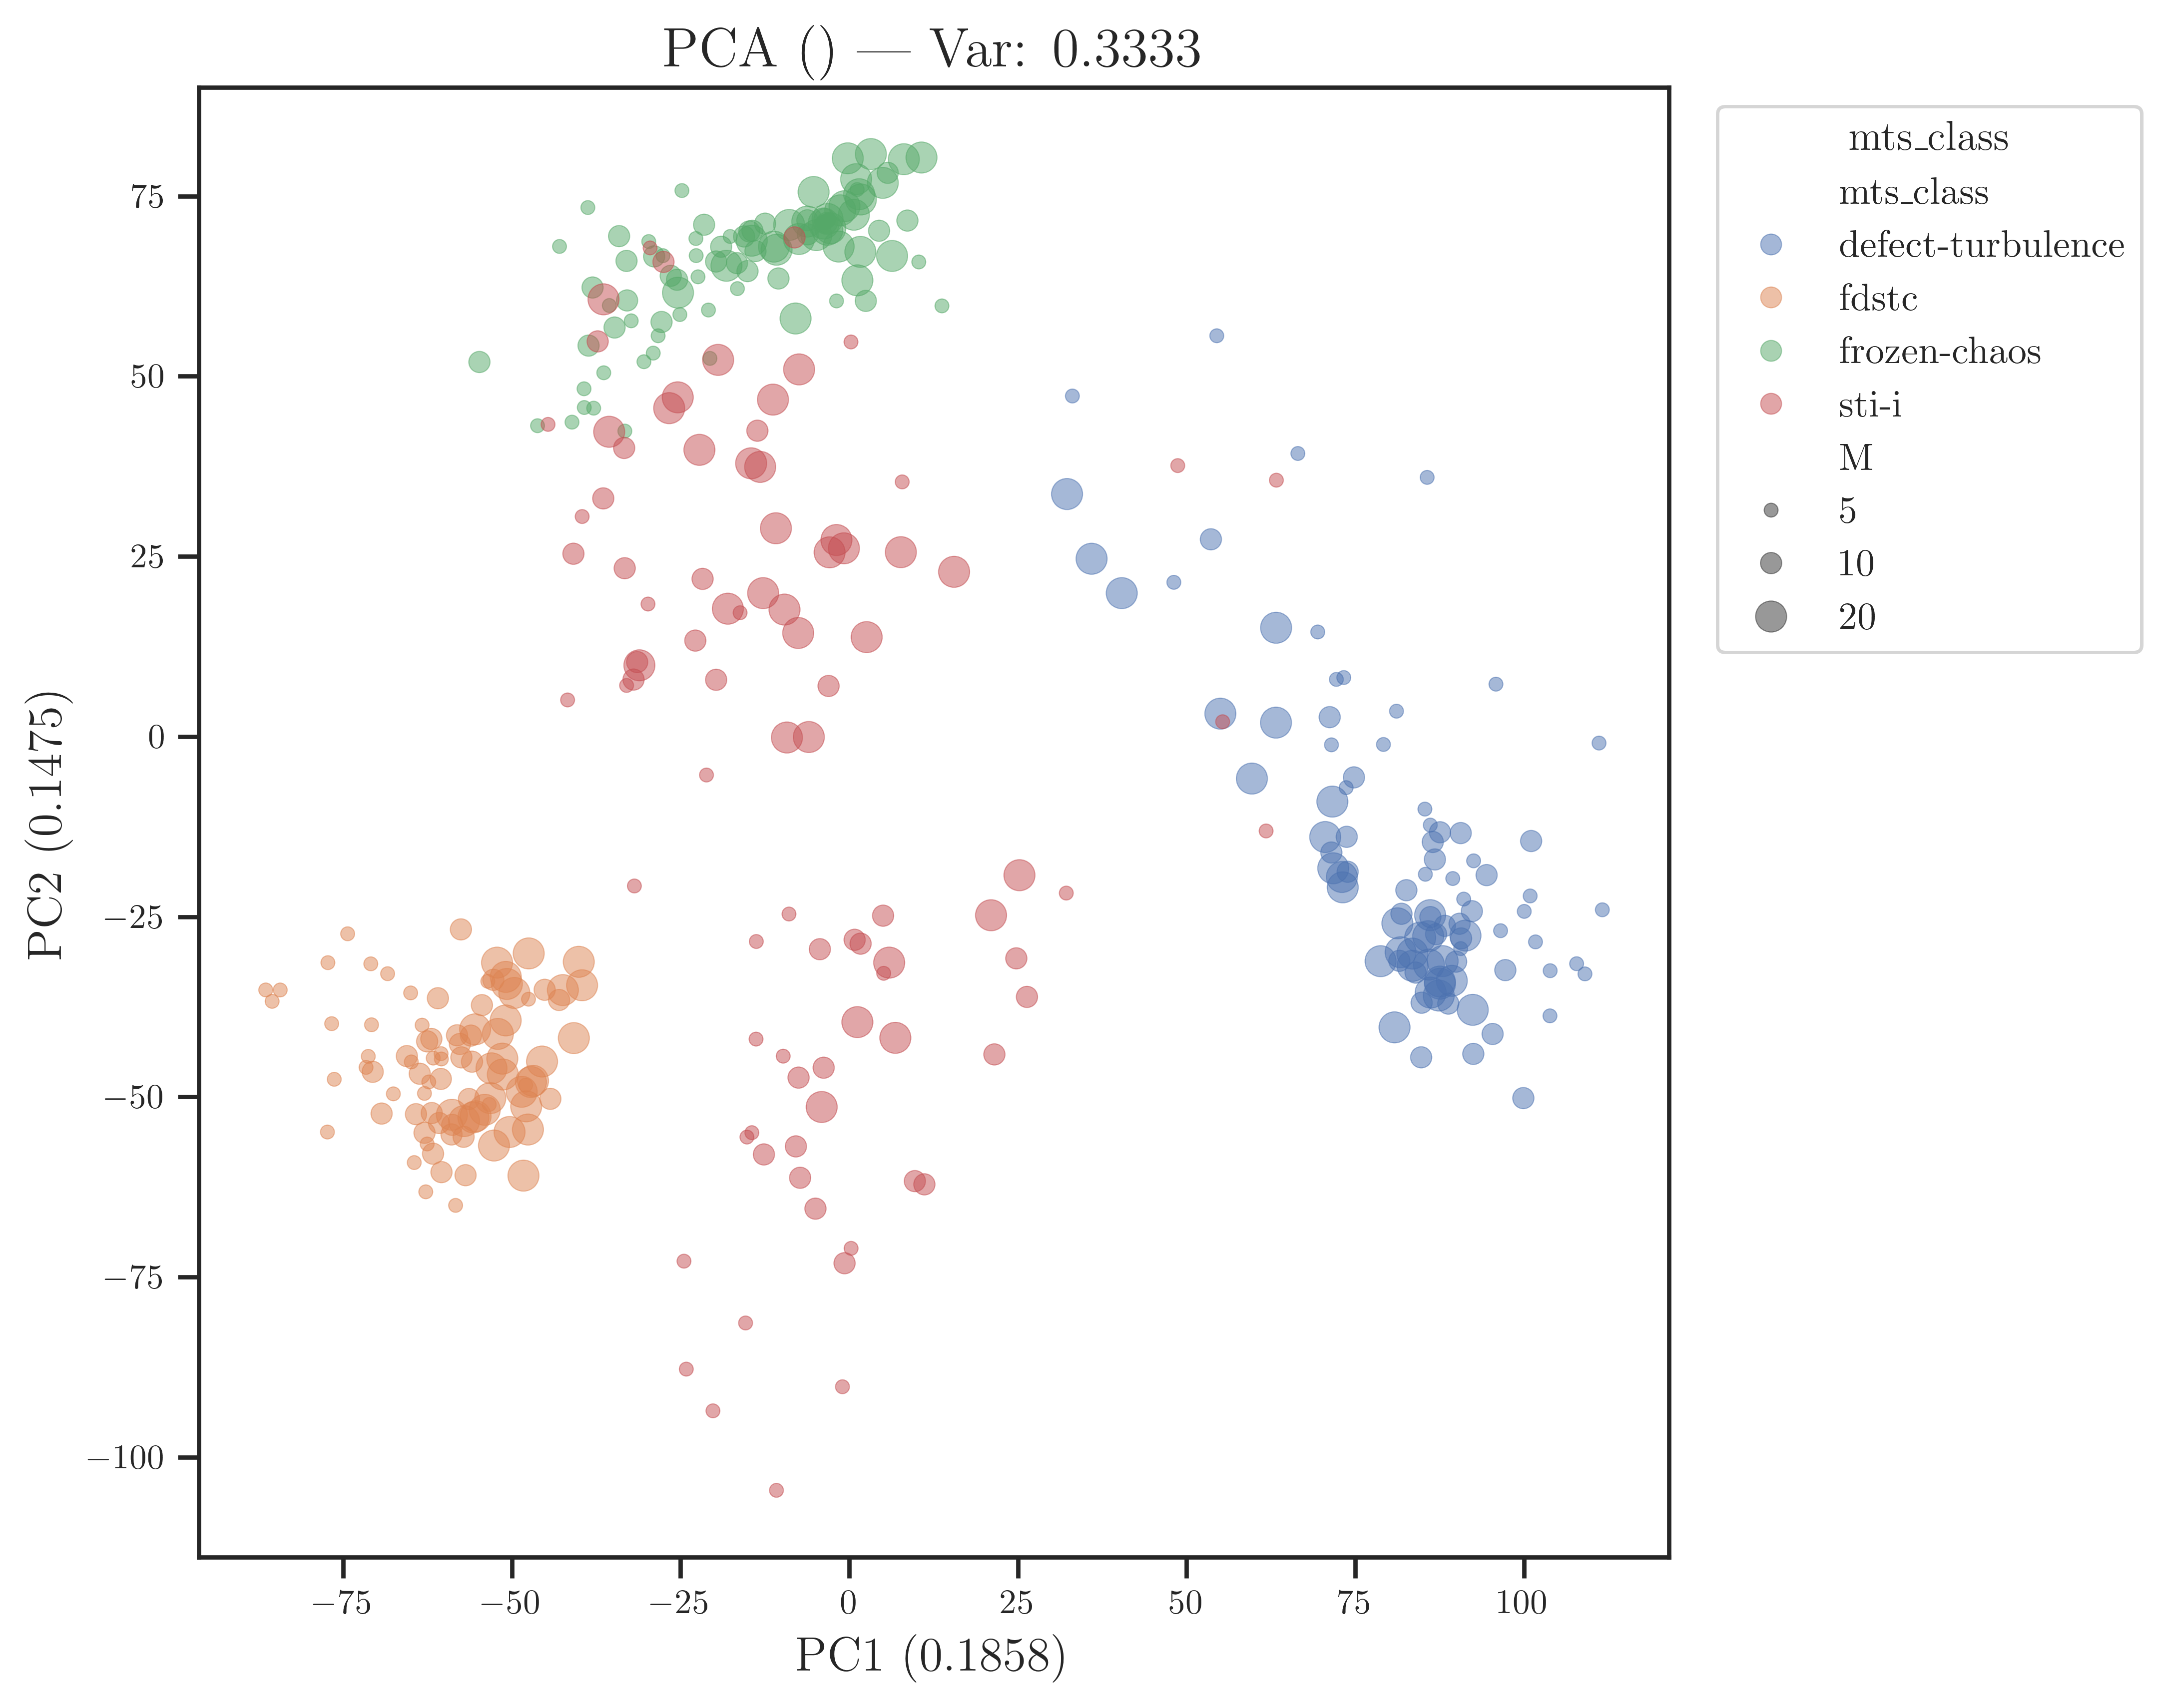

In [46]:
alpha=0.5
s=40
kde=False
ax=True

fig, ax = plt.subplots(figsize=(10, 7), dpi=500)
plot_pca(X, meta_df, alpha=alpha, s=s, ax=ax, kde=kde)
plt.tight_layout(); plt.show()

##### PCA - 3D

In [47]:
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 3D PCA on scaled features (matches plot_pca's StandardScaler step).
X_scaled = StandardScaler().fit_transform(X)
pca3 = PCA(n_components=3, random_state=0)
emb3 = pca3.fit_transform(X_scaled)
var3 = pca3.explained_variance_ratio_

df3 = meta_df.assign(
    pc1=emb3[:, 0], pc2=emb3[:, 1], pc3=emb3[:, 2],
    instance_str=meta_df["instance"].astype(str),
    dataset_paths_str=meta_df["dataset_paths"].astype(str),
)

fig = px.scatter_3d(
    df3, x="pc1", y="pc2", z="pc3",
    color="mts_class",
    size="M", size_max=16,
    hover_data={
        "mts_class": True, "M": True, "T": True,
        "instance_str": True, "dataset_paths_str": False,
        "pc1": ":.2f", "pc2": ":.2f", "pc3": ":.2f",
    },
    title=f"PCA 3D | Var: {var3.sum():.4f}  (PC1 {var3[0]:.3f}, PC2 {var3[1]:.3f}, PC3 {var3[2]:.3f})",
    width=1200, height=900,
)
fig.update_traces(marker=dict(opacity=0.55))
fig.update_layout(legend=dict(title="mts_class"),
                  scene=dict(xaxis_title=f"PC1 ({var3[0]:.3f})",
                             yaxis_title=f"PC2 ({var3[1]:.3f})",
                             zaxis_title=f"PC3 ({var3[2]:.3f})",
                             aspectmode="cube"))
fig.show()


##### UMAP - 2D

/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


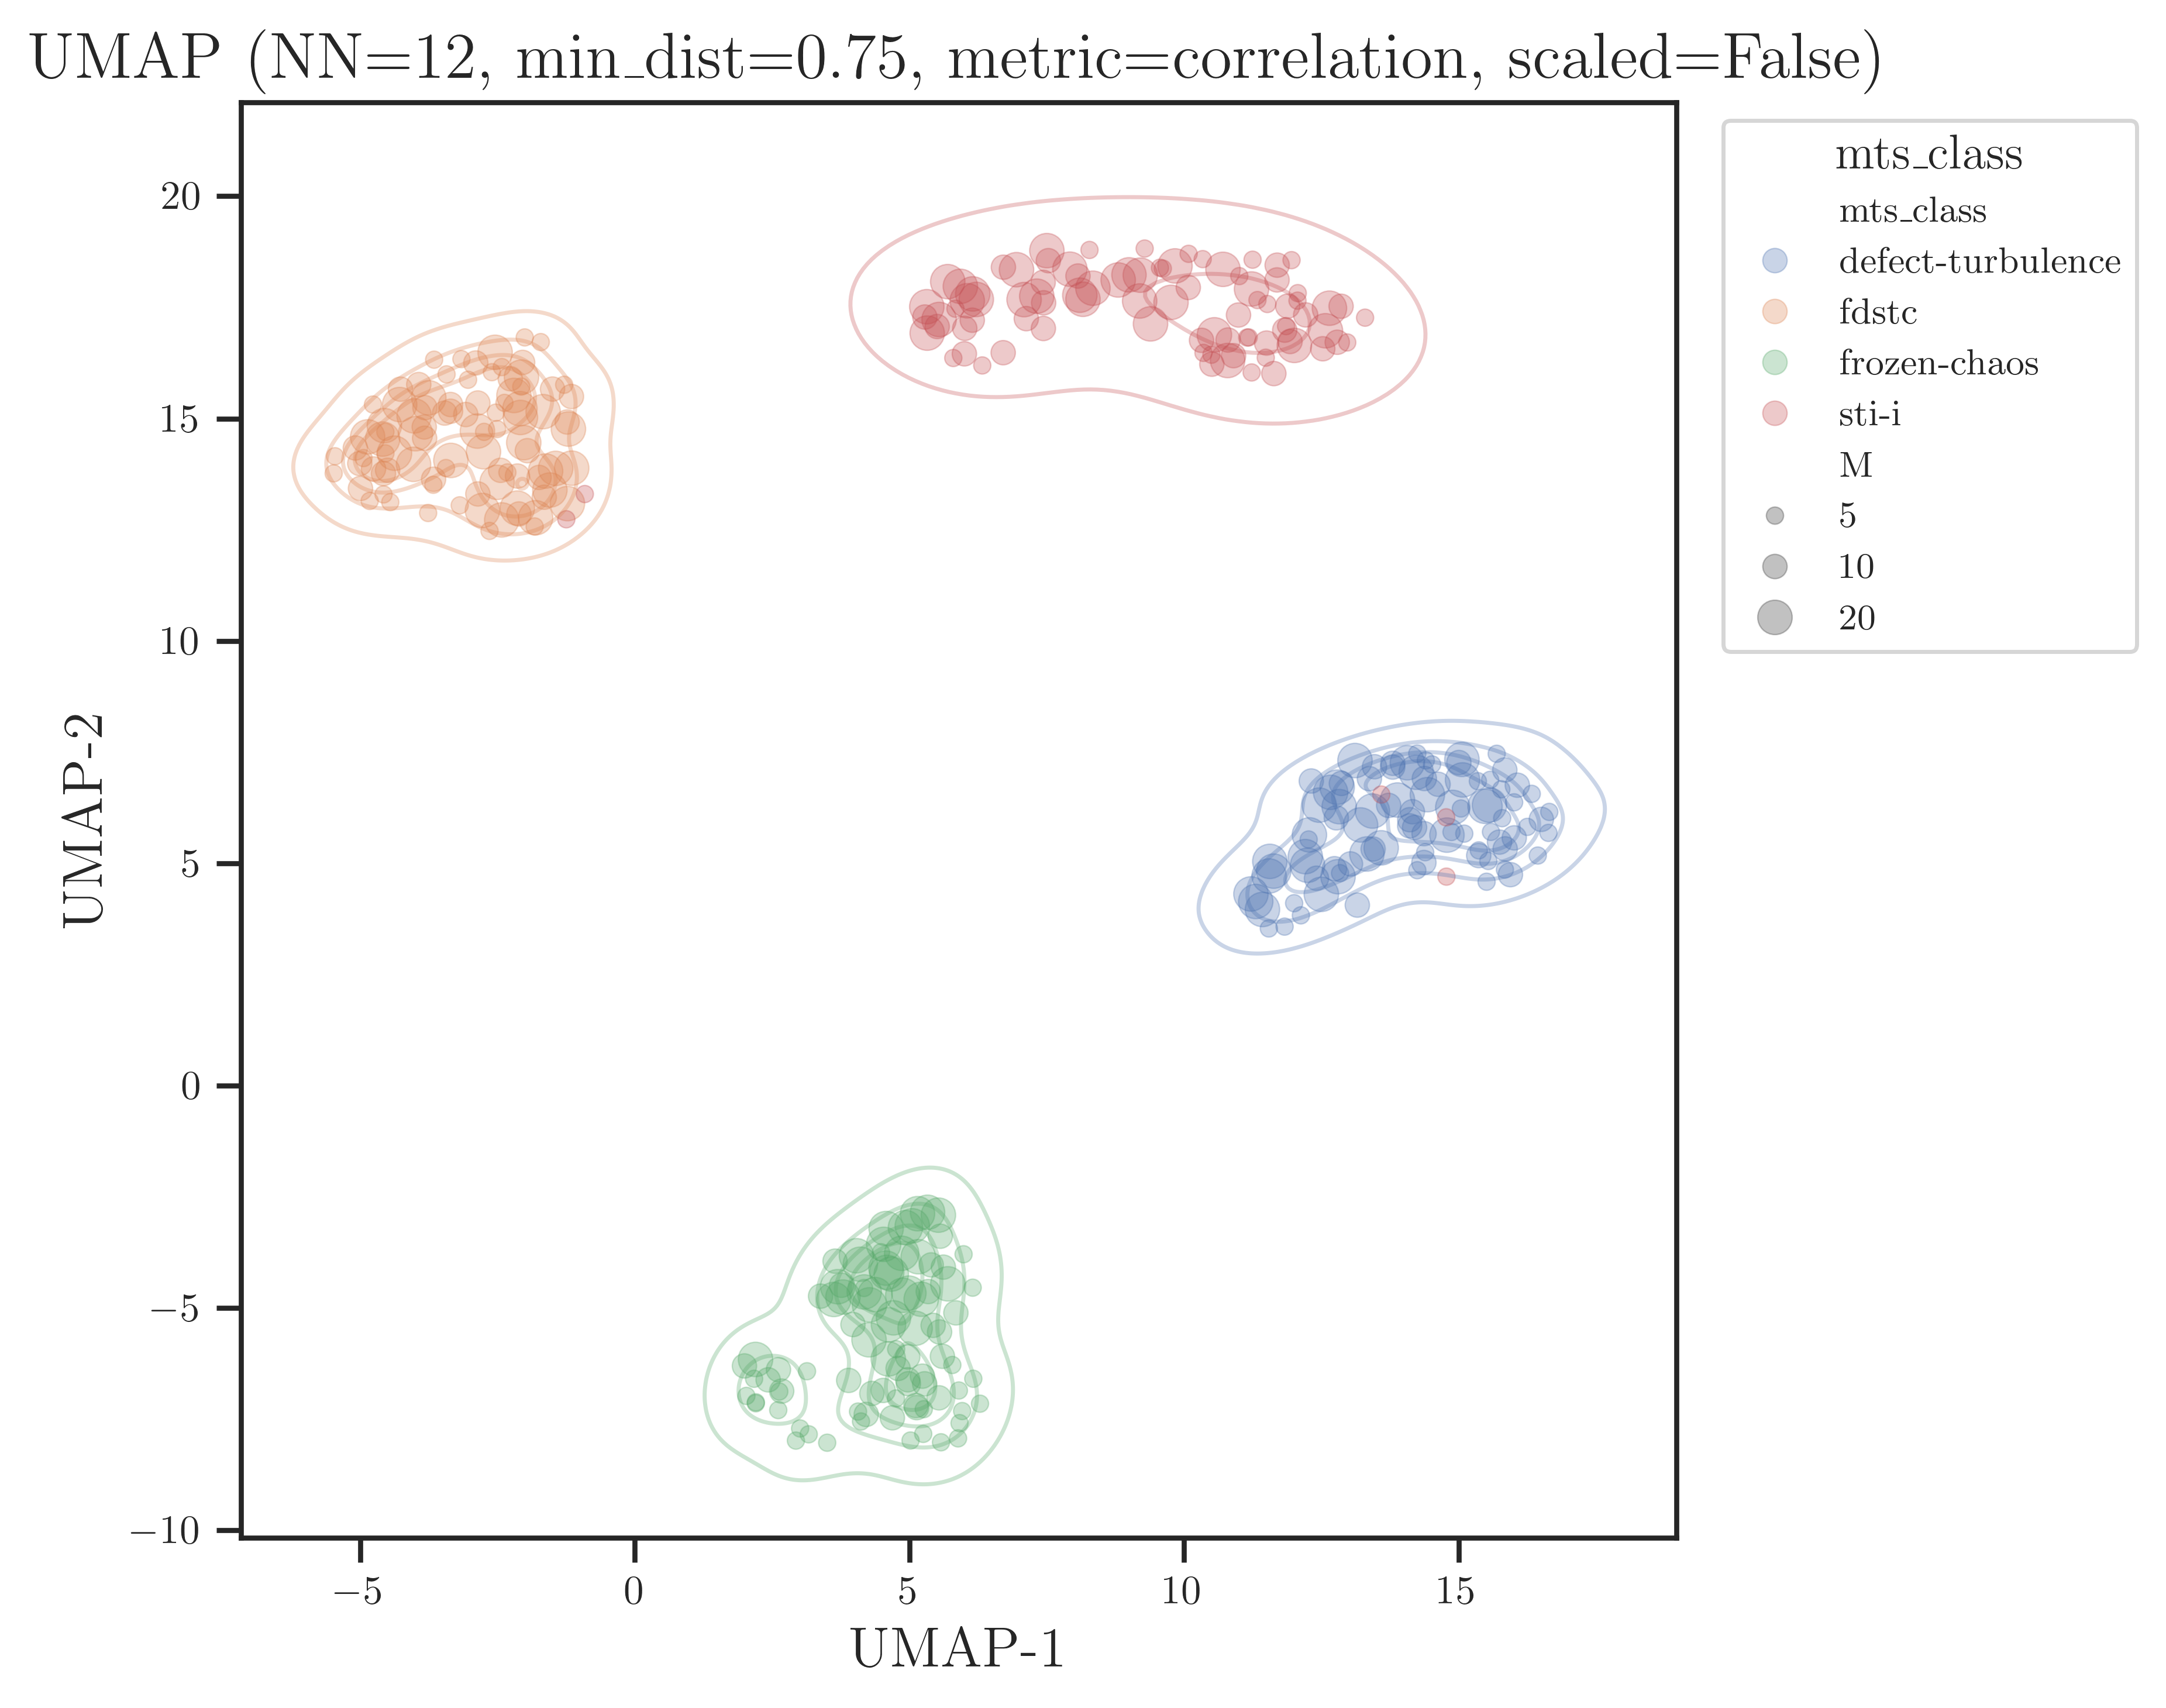

In [48]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from umap import UMAP

# Shared UMAP hyperparameters.
n_neighbors = 12
min_dist = 0.75
metric = "correlation"   # "euclidean" | "correlation" | "cosine"
scaled = False           # True -> StandardScaler(X); False -> raw X

X_input = StandardScaler().fit_transform(X) if scaled else X
emb = UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric=metric,
                  random_state=0, verbose=False).fit_transform(X_input)

df_emb = meta_df.assign(umap_x=emb[:, 0], umap_y=emb[:, 1])

fig, ax = plt.subplots(figsize=(8, 6), dpi=500)
sns.kdeplot(data=df_emb, x="umap_x", y="umap_y", hue="mts_class",
            levels=5, alpha=0.3, linewidths=1, ax=ax, legend=False)
sns.scatterplot(data=df_emb, x="umap_x", y="umap_y",
                hue="mts_class", size="M",
                alpha=0.3, edgecolor="face", ax=ax, legend="full")
ax.set_title(f"UMAP (NN={n_neighbors}, min_dist={min_dist}, metric={metric}, scaled={scaled})")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.set_box_aspect(1)
ax.legend(title="mts_class", loc="upper left", bbox_to_anchor=(1.02, 1),
          fontsize=9, frameon=True)
plt.tight_layout()
plt.savefig("../../notebooks/embeddings/graphics/umap_cml_small.svg", dpi=500, bbox_inches="tight")
plt.show()

In [49]:
import plotly.express as px

# Interactive version of the chosen combo (emb_chosen / chosen_label from the cell above).
df_plot = meta_df.assign(
    umap_x=emb[:, 0],
    umap_y=emb[:, 1],
    M_str=meta_df["M"].astype(str),
    instance_str=meta_df["instance"].astype(str),
    dataset_paths_str=meta_df["dataset_paths"].astype(str),
)
fig = px.scatter(
    df_plot, x="umap_x", y="umap_y",
    color="mts_class",
    symbol="M_str",
    hover_data={
        "mts_class": True,
        "M": True,
        "T": True,
        "instance_str": True,
        "dataset_paths_str": False,
        "M_str": False,
        "umap_x": ":.2f",
        "umap_y": ":.2f",
    },
    title=f"UMAP (NN={n_neighbors}, min_dist={min_dist}, metric={metric}, {'scaled' if scaled else 'raw'})",
    width=900, height=700,
)
fig.update_traces(marker=dict(size=9, opacity=0.75))
fig.update_layout(legend=dict(title="mts_class / M"))
fig.show()